In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector

print('All the libearies loaded successfully')

All the libearies loaded successfully


In [3]:
!pip install mysql-connector-python

In [4]:
df= pd.read_csv('loan_default.csv')
#first look
print("shape", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

shape (255347, 18)

Column Names:
['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']

First 5 rows:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
print("missing values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Stats:")
df.describe()

missing values:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

Data Types:
LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

Basic Stats:


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [6]:
df= df.drop_duplicates()
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [12]:
print("Cleaned Shape:", df.shape)
print("Columns:", df.columns.tolist())

Cleaned Shape: (255347, 18)
Columns: ['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [13]:
df.to_csv('loan_default_clean.csv', index=False)
print("Clean file saved!")

Clean file saved!


In [14]:
!pip install sqlalchemy

In [19]:
import os
print(os.getcwd())

C:\Users\Shreya


In [20]:
print(df.columns.tolist())
print("\n")
print(df.head(2))

['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio   Education  \
0               4         15.23        36      0.44  Bachelor's   
1               1          4.81        60      0.68    Master's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorced         Yes           Yes       Other   
1      Full-time       Married          No            No       Other   

  HasCoSigner  Default  
0         Yes        0  
1         Yes        0  


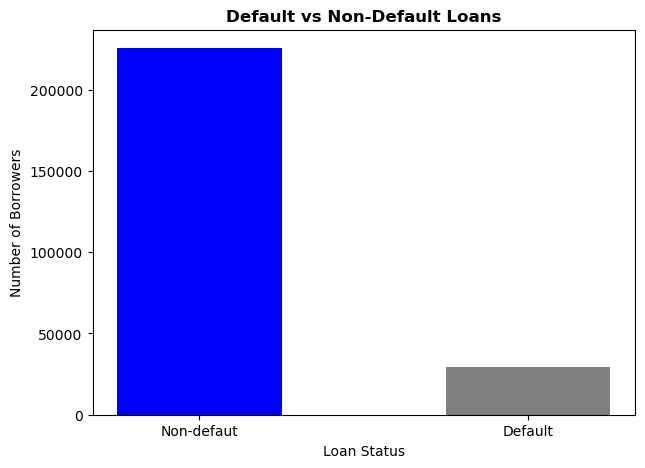

Chart 1 saved!


In [31]:
default_counts = df['Default'].value_counts()
plt.figure(figsize = (7,5))
plt.bar (['Non-defaut' , 'Default'] , default_counts.values,
         color=['Blue','Grey'], width=0.5)
plt.title('Default vs Non-Default Loans', fontweight='bold')
plt.ylabel('Number of Borrowers')
plt.xlabel('Loan Status')
plt.savefig(r'C:\Users\Shreya\Desktop\chart1_default_count.png', dpi=150)
plt.show()
print("Chart 1 saved!")

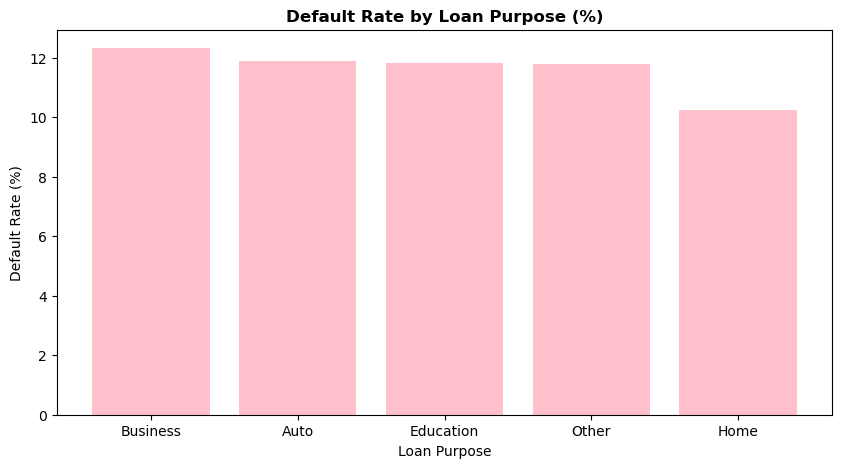

Chart 2 saved!


In [43]:
purpose_default = df.groupby('LoanPurpose')['Default'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
plt.bar(purpose_default.index, purpose_default.values, color='pink')
plt.title('Default Rate by Loan Purpose (%)', fontweight='bold')
plt.xlabel('Loan Purpose')
plt.ylabel('Default Rate (%)')
plt.savefig(r'C:\Users\Shreya\Desktop\chart2_purpose_default.png', dpi=150)
plt.show()
print("Chart 2 saved!")

C:\Users\Shreya\AppData\Local\Temp\ipykernel_25576\3745770280.py:10: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(r'C:\Users\Shreya\Desktop\chart4_creditscore_interest.png', dpi=150)
C:\Users\Shreya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


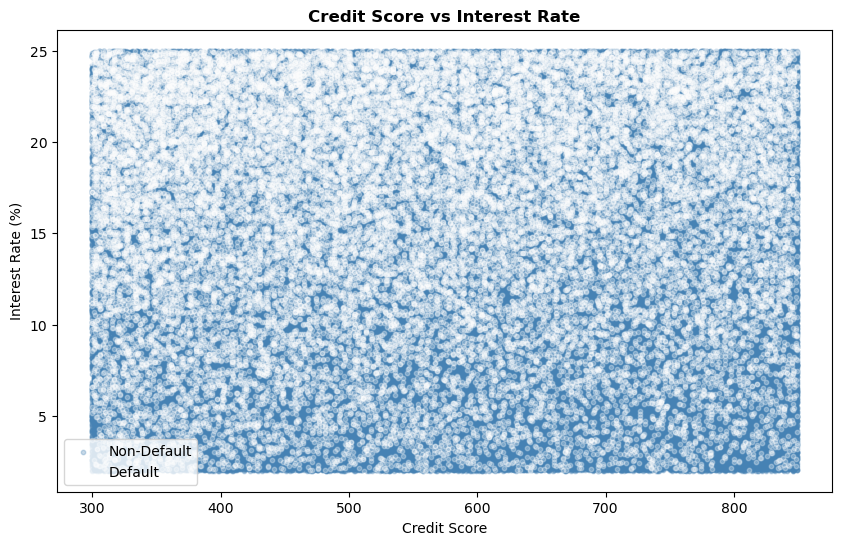

Chart 3 saved!


In [39]:
default_yes = df[df['Default']==1]
default_no = df[df['Default']==0]
plt.figure(figsize=(10, 6))
plt.scatter (default_no['CreditScore'], default_no['InterestRate'], color='steelblue', alpha=0.3, s=10, label='Non-Default')
plt.scatter(default_yes['CreditScore'], default_yes['InterestRate'], color='white',alpha=0.3, s=10, label='Default')
plt.title('Credit Score vs Interest Rate', fontweight='bold')
plt.xlabel('Credit Score')
plt.ylabel('Interest Rate (%)')
plt.legend()
plt.savefig(r'C:\Users\Shreya\Desktop\chart4_creditscore_interest.png', dpi=150)
plt.show()
print("Chart 3 saved!")


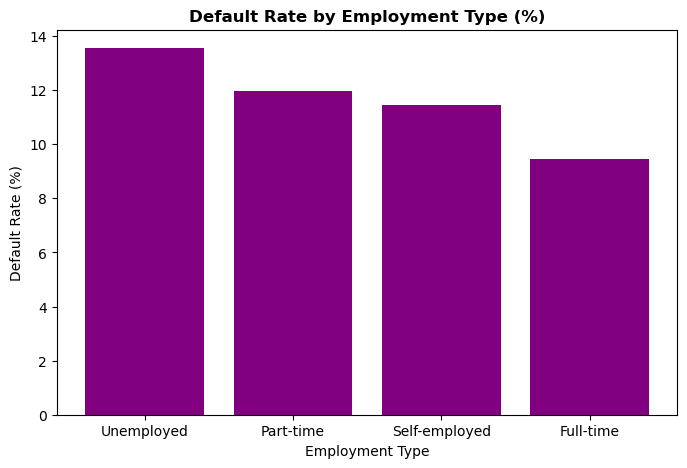

Chart 4 saved!


In [45]:
emp_default = df.groupby('EmploymentType')['Default'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
plt.bar(emp_default.index, emp_default.values, color='purple')
plt.title('Default Rate by Employment Type (%)', fontweight='bold')
plt.xlabel('Employment Type')
plt.ylabel('Default Rate (%)')
plt.savefig(r'C:\Users\Shreya\Desktop\chart3_employment_default.png', dpi=150)
plt.show()
print("Chart 4 saved!")

In [9]:
import sqlite3

conn = sqlite3.connect('loan_analysis.db')
df.to_sql('loan_default', conn, if_exists='replace', index=False)
print("Data loaded! Rows:", pd.read_sql('SELECT COUNT(*) FROM loan_default', conn).values[0][0])

Data loaded! Rows: 255347


In [11]:
query1 = """
SELECT 
    COUNT(*) AS Total_Loans,
    SUM(`Default`) AS Total_Defaults,
    ROUND(SUM(`Default`)*100.0/COUNT(*), 2) AS Default_Rate_Percent
FROM loan_default
"""
result1 = pd.read_sql(query1, conn)
print("=== Overall Default Rate ===")
print(result1)

=== Overall Default Rate ===
   Total_Loans  Total_Defaults  Default_Rate_Percent
0       255347           29653                 11.61


In [12]:
query2 = """
SELECT 
    LoanPurpose,
    COUNT(*) AS Total_Loans,
    SUM(`Default`) AS Total_Defaults,
    ROUND(SUM(`Default`)*100.0/COUNT(*), 2) AS Default_Rate_Percent
FROM loan_default
GROUP BY LoanPurpose
ORDER BY Default_Rate_Percent DESC
"""
result2 = pd.read_sql(query2, conn)
print("=== Default Rate by Loan Purpose ===")
print(result2)

=== Default Rate by Loan Purpose ===
  LoanPurpose  Total_Loans  Total_Defaults  Default_Rate_Percent
0    Business        51298            6323                 12.33
1        Auto        50844            6041                 11.88
2   Education        51005            6038                 11.84
3       Other        50914            6002                 11.79
4        Home        51286            5249                 10.23


In [13]:
query3 = """
SELECT 
    CASE 
        WHEN Income < 30000 THEN 'Low Income'
        WHEN Income BETWEEN 30000 AND 60000 THEN 'Middle Income'
        WHEN Income BETWEEN 60000 AND 100000 THEN 'Upper Middle'
        ELSE 'High Income'
    END AS Income_Group,
    COUNT(*) AS Total_Loans,
    SUM(`Default`) AS Total_Defaults,
    ROUND(SUM(`Default`)*100.0/COUNT(*), 2) AS Default_Rate_Percent
FROM loan_default
GROUP BY Income_Group
ORDER BY Default_Rate_Percent DESC
"""
result3 = pd.read_sql(query3, conn)
print("=== Default Rate by Income Group ===")
print(result3)

=== Default Rate by Income Group ===
    Income_Group  Total_Loans  Total_Defaults  Default_Rate_Percent
0     Low Income        28402            6236                 21.96
1  Middle Income        56653            7242                 12.78
2   Upper Middle        75727            7566                  9.99
3    High Income        94565            8609                  9.10


In [14]:
query4 = """
SELECT 
    EmploymentType,
    COUNT(*) AS Total_Loans,
    SUM(`Default`) AS Total_Defaults,
    ROUND(SUM(`Default`)*100.0/COUNT(*), 2) AS Default_Rate_Percent
FROM loan_default
GROUP BY EmploymentType
ORDER BY Default_Rate_Percent DESC
"""
result4 = pd.read_sql(query4, conn)
print("=== Default Rate by Employment Type ===")
print(result4)

=== Default Rate by Employment Type ===
  EmploymentType  Total_Loans  Total_Defaults  Default_Rate_Percent
0     Unemployed        63824            8650                 13.55
1      Part-time        64161            7677                 11.97
2  Self-employed        63706            7302                 11.46
3      Full-time        63656            6024                  9.46


In [15]:
query5 = """
SELECT 
    Education,
    COUNT(*) AS Total_Loans,
    SUM(`Default`) AS Total_Defaults,
    ROUND(SUM(`Default`)*100.0/COUNT(*), 2) AS Default_Rate_Percent
FROM loan_default
GROUP BY Education
ORDER BY Default_Rate_Percent DESC
"""
result5 = pd.read_sql(query5, conn)
print("=== Default Rate by Education Level ===")
print(result5)

=== Default Rate by Education Level ===
     Education  Total_Loans  Total_Defaults  Default_Rate_Percent
0  High School        63903            8230                 12.88
1   Bachelor's        64366            7789                 12.10
2     Master's        63541            6908                 10.87
3          PhD        63537            6726                 10.59


In [16]:
query6 = """
SELECT
    CASE
        WHEN CreditScore < 500 AND InterestRate > 20 THEN 'Very High Risk'
        WHEN CreditScore BETWEEN 500 AND 600 AND InterestRate > 15 THEN 'High Risk'
        WHEN CreditScore BETWEEN 600 AND 700 THEN 'Medium Risk'
        ELSE 'Low Risk'
    END AS Risk_Segment,
    COUNT(*) AS Total_Accounts,
    SUM(`Default`) AS Total_Defaults,
    ROUND(SUM(`Default`)*100.0/COUNT(*), 2) AS Default_Rate_Percent
FROM loan_default
GROUP BY Risk_Segment
ORDER BY Default_Rate_Percent DESC
"""
result6 = pd.read_sql(query6, conn)
print("=== Risk Segmentation ===")
print(result6)

=== Risk Segmentation ===
     Risk_Segment  Total_Accounts  Total_Defaults  Default_Rate_Percent
0  Very High Risk           20265            3943                 19.46
1       High Risk           20235            3230                 15.96
2     Medium Risk           46703            5212                 11.16
3        Low Risk          168144           17268                 10.27


In [17]:
query7 = """
SELECT 
    CASE WHEN `Default` = 1 THEN 'Defaulted' ELSE 'Non-Defaulted' END AS Loan_Status,
    ROUND(AVG(Age), 1) AS Avg_Age,
    ROUND(AVG(Income), 0) AS Avg_Income,
    ROUND(AVG(LoanAmount), 0) AS Avg_LoanAmount,
    ROUND(AVG(CreditScore), 0) AS Avg_CreditScore,
    ROUND(AVG(InterestRate), 2) AS Avg_InterestRate,
    ROUND(AVG(DTIRatio), 2) AS Avg_DTI_Ratio
FROM loan_default
GROUP BY `Default`
"""
result7 = pd.read_sql(query7, conn)
print("=== Average Profile: Default vs Non-Default ===")
print(result7)

=== Average Profile: Default vs Non-Default ===
     Loan_Status  Avg_Age  Avg_Income  Avg_LoanAmount  Avg_CreditScore  \
0  Non-Defaulted     44.4     83899.0        125354.0            576.0   
1      Defaulted     36.6     71845.0        144515.0            559.0   

   Avg_InterestRate  Avg_DTI_Ratio  
0             13.18           0.50  
1             15.90           0.51  


In [18]:
query8 = """
SELECT
    COUNT(*) AS Total_Borrowers,
    ROUND(AVG(LoanAmount), 0) AS Avg_Loan_Amount,
    ROUND(AVG(Income), 0) AS Avg_Borrower_Income,
    ROUND(AVG(CreditScore), 0) AS Avg_Credit_Score,
    ROUND(AVG(InterestRate), 2) AS Avg_Interest_Rate,
    ROUND(SUM(`Default`)*100.0/COUNT(*), 2) AS Overall_Default_Rate_Percent,
    COUNT(DISTINCT LoanPurpose) AS Loan_Categories,
    COUNT(DISTINCT EmploymentType) AS Employment_Types
FROM loan_default
"""
result8 = pd.read_sql(query8, conn)
print("=== Executive Summary ===")
print(result8)

=== Executive Summary ===
   Total_Borrowers  Avg_Loan_Amount  Avg_Borrower_Income  Avg_Credit_Score  \
0           255347         127579.0              82499.0             574.0   

   Avg_Interest_Rate  Overall_Default_Rate_Percent  Loan_Categories  \
0              13.49                         11.61                5   

   Employment_Types  
0                 4  
